In [3]:
import pandas as pd

df = pd.read_csv('/content/twitter_training (1).csv', header=None, names=['id', 'entity', 'sentiment', 'tweet_text'])

df.dropna(subset=['tweet_text'], inplace=True)

display(df.head())

,id,entity,sentiment,tweet_text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73824 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          73824 non-null  int64 
 1   entity      73824 non-null  object
 2   sentiment   73824 non-null  object
 3   tweet_text  73824 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.8+ MB


In [6]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re

nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()


df['preprocessed_text'] = df['tweet_text'].apply(preprocess_text)

def get_vader_sentiment(text):
    sentiment = sia.polarity_scores(text)

    if sentiment['compound'] >= 0.05:
        return 'Positive'
    elif sentiment['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['preprocessed_text'].apply(get_vader_sentiment)

display(df.head())

,id,entity,sentiment,tweet_text,preprocessed_text,vader_sentiment
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,Negative
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,Negative
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,Negative
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,Negative
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder y...,Negative


In [7]:
vader_sentiment_distribution = df['vader_sentiment'].value_counts()

print("VADER Sentiment Distribution:")
print(vader_sentiment_distribution)

VADER Sentiment Distribution:
vader_sentiment
Positive    33341
Negative    27609
Neutral     12874
Name: count, dtype: int64


In [8]:
original_sentiment_distribution = df['sentiment'].value_counts()

print("Original Sentiment Distribution:")
print(original_sentiment_distribution)

Original Sentiment Distribution:
sentiment
Negative      22312
Positive      20619
Neutral       18051
Irrelevant    12842
Name: count, dtype: int64


/tmp/ipykernel_18168/4185876261.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vader_sentiment_distribution.index, y=vader_sentiment_distribution.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_18168/4185876261.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=original_sentiment_distribution.index, y=original_sentiment_distribution.values, ax=axes[1], palette='magma')


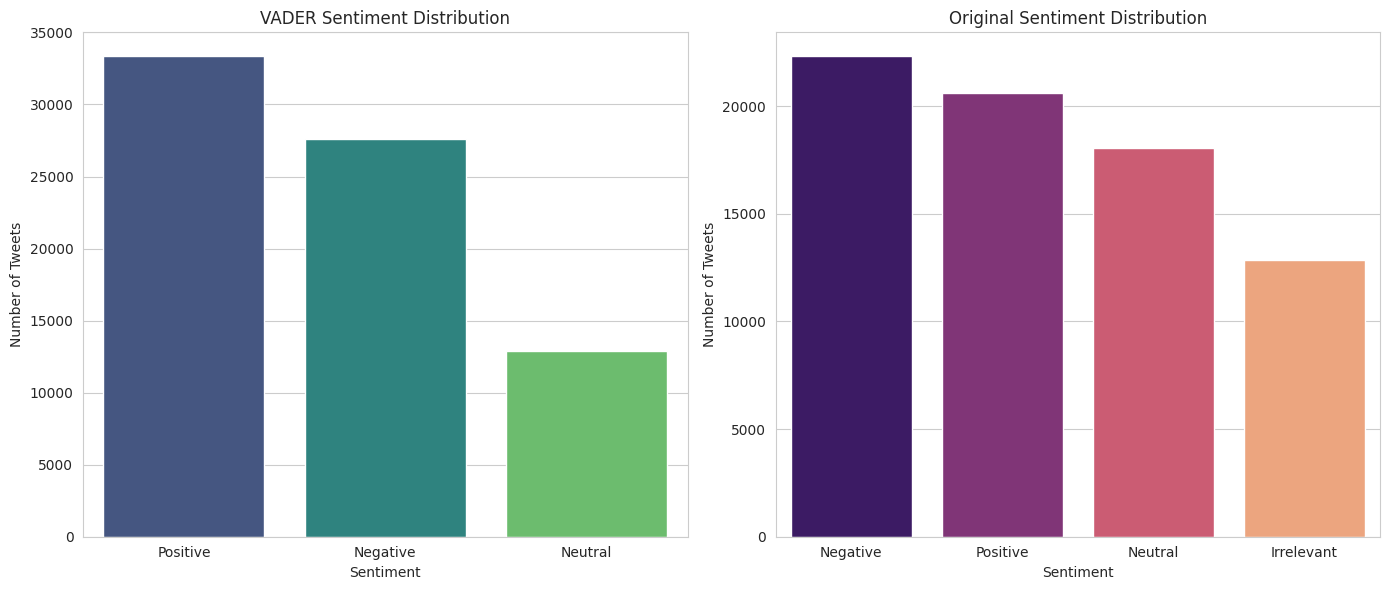

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=vader_sentiment_distribution.index, y=vader_sentiment_distribution.values, ax=axes[0], palette='viridis')
axes[0].set_title('VADER Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Tweets')

sns.barplot(x=original_sentiment_distribution.index, y=original_sentiment_distribution.values, ax=axes[1], palette='magma')
axes[1].set_title('Original Sentiment Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Tweets')

plt.tight_layout()
plt.show()

In [10]:
entity_distribution = df['entity'].value_counts()

print("Entity Distribution:")
print(entity_distribution)

Entity Distribution:
entity
LeagueOfLegends                      2372
CallOfDuty                           2371
MaddenNFL                            2370
Verizon                              2361
Facebook                             2360
Dota2                                2359
WorldOfCraft                         2356
TomClancysRainbowSix                 2354
Microsoft                            2349
ApexLegends                          2347
NBA2K                                2342
CallOfDutyBlackopsColdWar            2337
johnson&johnson                      2324
FIFA                                 2320
TomClancysGhostRecon                 2314
Overwatch                            2312
Battlefield                          2307
GrandTheftAuto(GTA)                  2291
HomeDepot                            2288
PlayStation5(PS5)                    2288
Hearthstone                          2284
CS-GO                                2280
Borderlands                          2280
Xbox(X

/tmp/ipykernel_18168/2239913894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=entity_distribution.index, y=entity_distribution.values, palette='cubehelix')


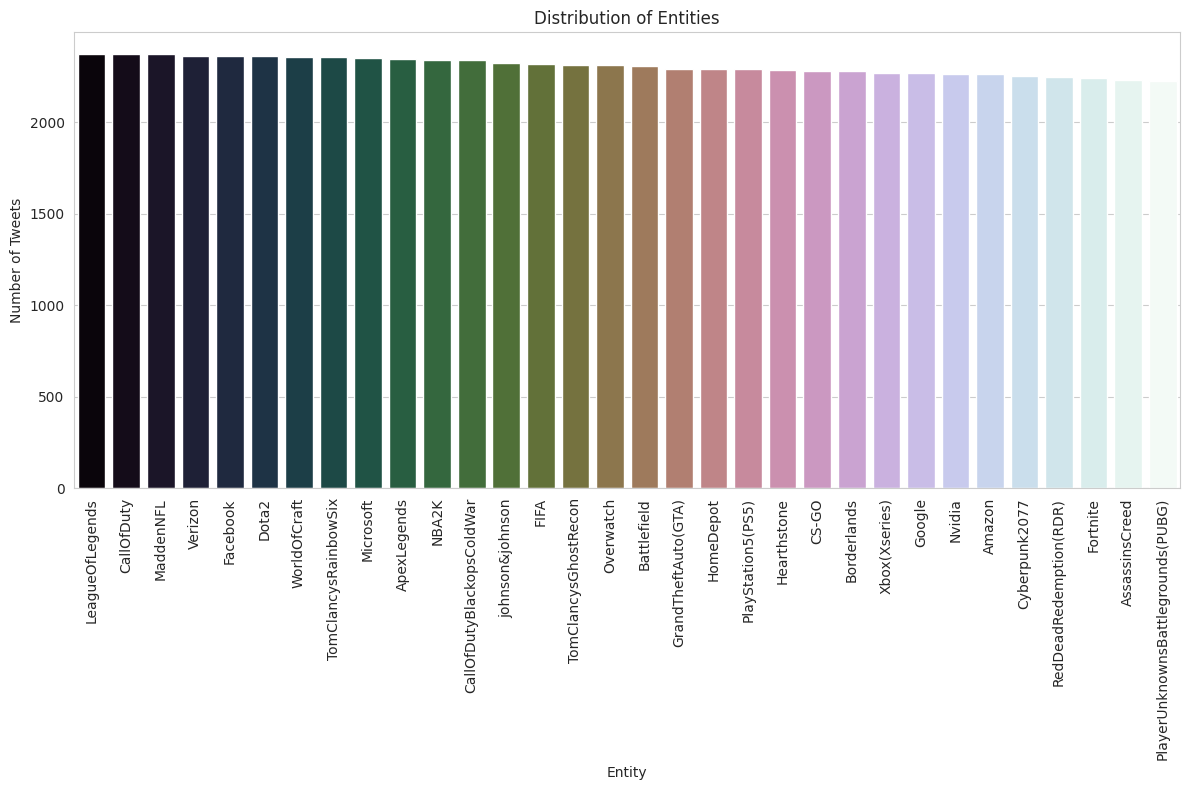

In [11]:
plt.figure(figsize=(12, 8))
sns.barplot(x=entity_distribution.index, y=entity_distribution.values, palette='cubehelix')
plt.title('Distribution of Entities')
plt.xlabel('Entity')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
sentiment_per_entity = df.groupby(['entity', 'vader_sentiment']).size().unstack(fill_value=0)

display(sentiment_per_entity.head())

vader_sentiment,Negative,Neutral,Positive
entity,,,
Amazon,625,217,1422
ApexLegends,783,474,1090
AssassinsCreed,556,357,1318
Battlefield,1154,254,899
Borderlands,616,375,1289


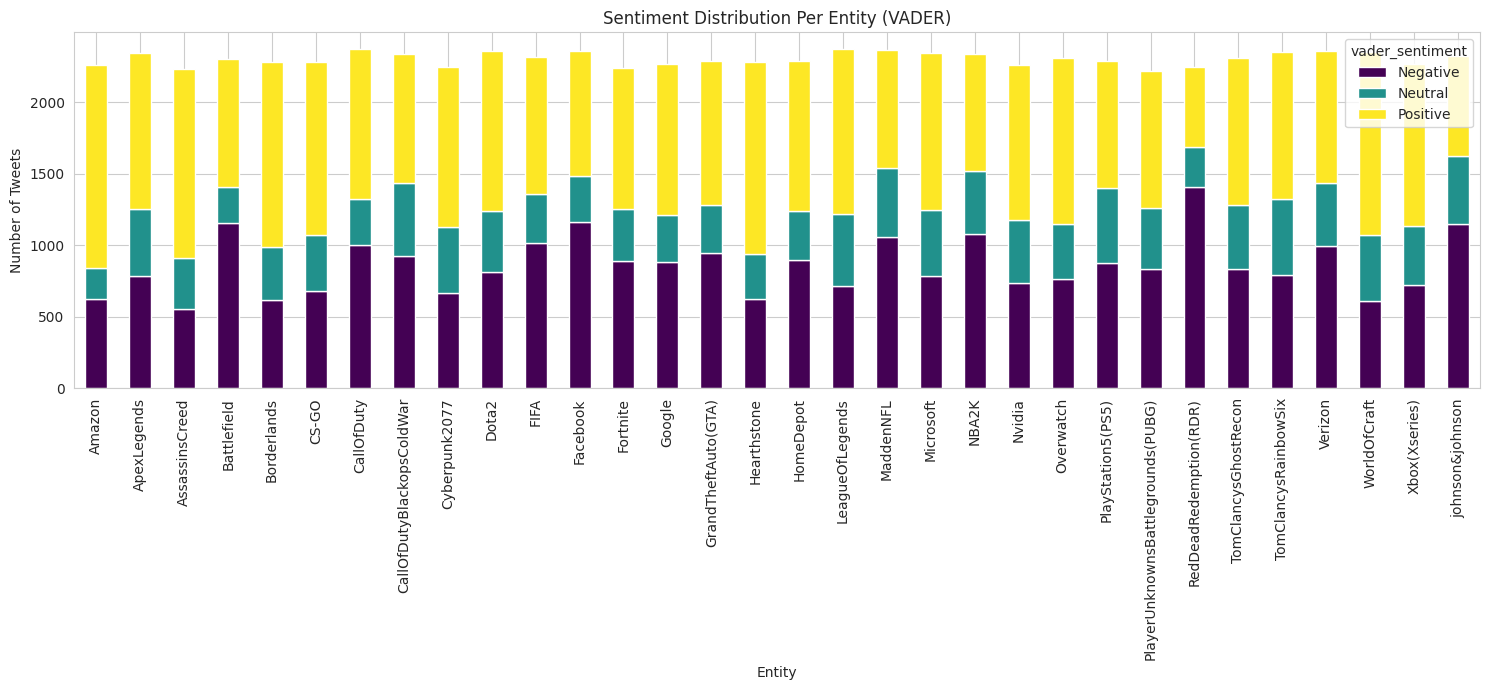

In [13]:
sentiment_per_entity.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='viridis')
plt.title('Sentiment Distribution Per Entity (VADER)')
plt.xlabel('Entity')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The entity distribution provides an overview of the different topics or brands present in the dataset and their respective tweet counts. This information is crucial for understanding the context of the sentiment analysis. Next, we will visualize this distribution to better comprehend the prevalence of each entity. Then, we will proceed to analyze the sentiment per entity to understand public opinion towards specific topics or brands.

The bar charts provide a visual comparison of the VADER sentiment distribution and the original sentiment distribution. We can observe the differences in categorization, especially the 'Irrelevant' category present in the original data but absent in VADER's output, and how 'Neutral' sentiments are handled differently. Now, let's further explore the `entity` column, which indicates the topic or brand, to understand sentiment patterns across different entities. I will start by examining the distribution of entities.

We now have both the VADER sentiment distribution and the original sentiment distribution. This allows us to compare how the VADER model's classifications align with the provided labels. We can see if there are any significant differences or agreement patterns. Next, we will visualize both sentiment distributions for better understanding.

The VADER sentiment distribution shows the counts for 'Positive', 'Negative', and 'Neutral' classifications based on the VADER model. Next, we will compare this with the original 'sentiment' column from the dataset to see how they align.

The `tweet_text` column has been preprocessed to clean the text, and VADER sentiment analysis has been applied. New columns, `preprocessed_text` and `vader_sentiment`, have been added to the DataFrame. The `vader_sentiment` column categorizes each tweet's sentiment as 'Positive', 'Negative', or 'Neutral'.

The `tweet_text` column has been preprocessed to clean the text, and VADER sentiment analysis has been applied. New columns, `preprocessed_text` and `vader_sentiment`, have been added to the DataFrame. The `vader_sentiment` column categorizes each tweet's sentiment as 'Positive', 'Negative', or 'Neutral'.

The dataset has been loaded. From the `df.head()` output, it appears to contain an unnamed column, `entity`, `sentiment`, and `tweet_text`. The `df.info()` output will provide more details on data types and non-null counts.